In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [15]:
df = pd.read_csv('gurgaon_properties_missing_value_imputation.csv')

In [16]:
df.shape

(3556, 19)

In [17]:
df.head()

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,description,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,smart world orchard,sector 61,1.41,12250.0,2.0,2.0,2,2.0,Under Construction,Situated in prime location of sector 61 on gol...,1150.0,1.0,0.0,0.0,0.0,0.0,1.0,76.0
1,flat,dlf the primus,sector 82a,2.85,10936.0,4.0,4.0,3+,2.0,New Property,A north facing 4 bhk resale flat is available ...,2179.0,0.0,1.0,0.0,0.0,0.0,2.0,174.0
2,flat,shapoorji pallonji joyville gurugram,sector 102,0.95,10383.0,2.0,2.0,2,14.0,Relatively New,"Club house, mini theater, squash court, swimmi...",915.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,house,independent,sector 7,1.20,11194.0,2.0,4.0,2,3.0,Old Property,5bhk residential house for resale in jyoti par...,1072.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,flat,hcbs sports ville,sohna road,0.27,4348.0,2.0,2.0,2,10.0,Relatively New,Raw flat as given by builder. Good location ne...,619.0,0.0,0.0,0.0,0.0,0.0,1.0,43.0


In [18]:
latlong = pd.read_csv('latlong.csv')

In [19]:
latlong

,sector,coordinates
0,sector 1,"28.3663° N, 76.9456° E"
1,sector 2,"28.5095° N, 77.0320° E"
2,sector 3,"28.4909° N, 77.0176° E"
3,sector 4,"28.4738° N, 77.0107° E"
4,sector 5,"28.4794° N, 77.0176° E"
...,...,...
124,sector 113,"28.5287° N, 77.0233° E"
125,sector 114,"28.5334° N, 77.0118° E"
126,sector 115,"28.5385° N, 77.0061° E"
127,gwal pahari,"28.4484° N, 77.0210° E"


In [20]:
latlong['latitude'] = latlong['coordinates'].str.split(',').str.get(0).str.split('°').str.get(0).astype('float')

In [21]:
latlong['longitude'] = latlong['coordinates'].str.split(',').str.get(1).str.split('°').str.get(0).astype('float')

In [22]:
latlong.head()

,sector,coordinates,latitude,longitude
0,sector 1,"28.3663° N, 76.9456° E",28.3663,76.9456
1,sector 2,"28.5095° N, 77.0320° E",28.5095,77.0320
2,sector 3,"28.4909° N, 77.0176° E",28.4909,77.0176
3,sector 4,"28.4738° N, 77.0107° E",28.4738,77.0107
4,sector 5,"28.4794° N, 77.0176° E",28.4794,77.0176


In [23]:
new_df = df.merge(latlong, on = 'sector')

In [24]:
new_df.columns

Index(['property_type', 'society', 'sector', 'price', 'price_per_sqft',
       'bedRoom', 'bathroom', 'balcony', 'floorNum', 'agePossession',
       'description', 'built_up_area', 'study room', 'servant room',
       'store room', 'pooja room', 'others', 'furnishing_type', 'luxury_score',
       'coordinates', 'latitude', 'longitude'],
      dtype='object')

In [25]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3287 entries, 0 to 3286
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   property_type    3287 non-null   object 
 1   society          3287 non-null   object 
 2   sector           3287 non-null   object 
 3   price            3287 non-null   float64
 4   price_per_sqft   3287 non-null   float64
 5   bedRoom          3287 non-null   float64
 6   bathroom         3287 non-null   float64
 7   balcony          3287 non-null   object 
 8   floorNum         3287 non-null   float64
 9   agePossession    3287 non-null   object 
 10  description      3287 non-null   object 
 11  built_up_area    3287 non-null   float64
 12  study room       3287 non-null   float64
 13  servant room     3287 non-null   float64
 14  store room       3287 non-null   float64
 15  pooja room       3287 non-null   float64
 16  others           3287 non-null   float64
 17  furnishing_typ

In [27]:
group_df = new_df.groupby('sector')[[
    'price', 'price_per_sqft', 'built_up_area', 'latitude', 'longitude'
]].mean()


In [28]:
group_df

,price,price_per_sqft,built_up_area,latitude,longitude
sector,,,,,
gwal pahari,3.192222,9585.777778,3056.166667,28.4484,77.0210
manesar,0.962258,4608.064516,2027.367742,28.3515,76.9428
sector 1,1.860000,8249.833333,2327.833333,28.3663,76.9456
sector 102,1.698491,10618.094340,1558.405660,28.4750,76.9715
sector 103,1.495000,7445.785714,1865.428571,28.4949,76.9845
...,...,...,...,...,...
sector 92,0.960000,5997.380000,1581.971800,28.4079,76.9153
sector 93,0.848889,8009.888889,1017.000000,28.4153,76.9326
sector 95,0.466167,5140.466667,5806.033333,28.4172,76.9081


In [29]:
fig = px.scatter_mapbox(group_df, lat="latitude", lon="longitude", color="price_per_sqft", size='built_up_area',
                  color_continuous_scale=px.colors.cyclical.IceFire, zoom=10,
                  mapbox_style="open-street-map",text=group_df.index)
fig.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_11652\860414701.py:1: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(group_df, lat="latitude", lon="longitude", color="price_per_sqft", size='built_up_area',


In [30]:
new_df.to_csv('data_viz1.csv',index=False)

In [31]:
df1 = pd.read_csv('gurgaon_properties.csv')

In [32]:
df1.head()

,property_name,property_type,society,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,address,floorNum,facing,agePossession,nearbyLocations,description,furnishDetails,features,rating
0,2 BHK Flat in Sector 61 Gurgaon,flat,smart world orchard,1.41,12250.0,1151.0,Built Up area: 1150 (106.84 sq.m.),2,2,2,study room,"Sector 61 Gurgaon, Gurgaon, Haryana",2.0,NaN,Dec 2023,"['Sector 55-56 Metro station', 'Bestech Centra...",Situated in prime location of sector 61 on gol...,[],"['Security / Fire Alarm', 'Intercom Facility',...",NaN
1,4 BHK Flat in Sector 82A Gurgaon,flat,dlf the primus,2.85,10936.0,2606.0,Super Built up area 2606(242.11 sq.m.)Carpet a...,4,4,3+,servant room,"2nd Floor Dlf Primus Sector-82a Gurgaon, Secto...",2.0,North-East,0 to 1 Year Old,"['Sapphire 83', 'NH 48', 'Cambridge Montessori...",A north facing 4 bhk resale flat is available ...,"['1 Water Purifier', '1 Fridge', '8 Fan', '1 E...","['Centrally Air Conditioned', 'Water purifier'...","['Green Area5 out of 5', 'Construction4.5 out ..."
2,4 BHK Flat in Sector 70A Gurgaon,flat,bptp astaire gardens,1.70,8947.0,1900.0,Carpet area: 1900 (176.52 sq.m.),4,3,3,not available,"Sector 70A Gurgaon, Gurgaon, Haryana",1.0,North-East,1 to 5 Year Old,"['Sector 54 Chowk Metro Station', 'Airia Mall'...","On gurgaon spr, good potential as this area is...","['6 Fan', '1 Exhaust Fan', '3 Geyser', '20 Lig...","['Feng Shui / Vaastu Compliant', 'Security / F...","['Green Area4 out of 5', 'Construction5 out of..."
3,2 BHK Flat in Sector 102 Gurgaon,flat,shapoorji pallonji joyville gurugram,0.95,10383.0,915.0,Built Up area: 915 (85.01 sq.m.)Carpet area: 8...,2,2,2,not available,"Sector 102, Sector 102 Gurgaon, Gurgaon, Haryana",14.0,North-West,undefined,NaN,"Club house, mini theater, squash court, swimmi...","['1 Light', 'No AC', 'No Bed', 'No Chimney', '...",NaN,"['Environment4 out of 5', 'Safety4 out of 5', ..."
4,5 Bedroom House for sale in Jyoti Park,house,independent,1.20,11194.0,1072.0,Built Up area: 1072 (99.59 sq.m.),5,4,2,not available,"Jyoti Park, Sector 7, Jyoti Park, Gurgaon, Har...",3.0,NaN,undefined,"['State bank ATM', 'Dr. Madan Clinic', 'Taneja...",5bhk residential house for resale in jyoti par...,"['1 Light', 'No AC', 'No Bed', 'No Chimney', '...",NaN,"['Environment4 out of 5', 'Lifestyle4 out of 5..."


In [33]:
wordcloud_df = df1.merge(df, left_index=True, right_index=True)[['features','sector']]

In [34]:
wordcloud_df.head()

,features,sector
0,"['Security / Fire Alarm', 'Intercom Facility',...",sector 61
1,"['Centrally Air Conditioned', 'Water purifier'...",sector 82a
2,"['Feng Shui / Vaastu Compliant', 'Security / F...",sector 102
3,NaN,sector 7
4,NaN,sohna road


In [35]:
import ast
main = []
for item in wordcloud_df['features'].dropna().apply(ast.literal_eval):
    main.extend(item)

In [36]:
main

['Security / Fire Alarm',
 'Intercom Facility',
 'Lift(s)',
 'Maintenance Staff',
 'Water Storage',
 'Visitor Parking',
 'Swimming Pool',
 'Park',
 'Security Personnel',
 'Shopping Centre',
 'Fitness Centre / GYM',
 'Club house / Community Center',
 'Water softening plant',
 'Centrally Air Conditioned',
 'Water purifier',
 'Security / Fire Alarm',
 'Power Back-up',
 'Feng Shui / Vaastu Compliant',
 'Private Garden / Terrace',
 'Intercom Facility',
 'Lift(s)',
 'High Ceiling Height',
 'Maintenance Staff',
 'False Ceiling Lighting',
 'Water Storage',
 'Separate entry for servant room',
 'No open drainage around',
 'Bank Attached Property',
 'Piped-gas',
 'Internet/wi-fi connectivity',
 'Recently Renovated',
 'Visitor Parking',
 'Swimming Pool',
 'Park',
 'Security Personnel',
 'Natural Light',
 'Airy Rooms',
 'Spacious Interiors',
 'Low Density Society',
 'Waste Disposal',
 'Rain Water Harvesting',
 'Water softening plant',
 'Shopping Centre',
 'Fitness Centre / GYM',
 'Club house / Comm

In [38]:
from wordcloud import WordCloud

In [39]:
feature_text = ' '.join(main)

In [40]:
import pickle
pickle.dump(feature_text, open('feature_text.pkl','wb'))

In [41]:
feature_text

'Security / Fire Alarm Intercom Facility Lift(s) Maintenance Staff Water Storage Visitor Parking Swimming Pool Park Security Personnel Shopping Centre Fitness Centre / GYM Club house / Community Center Water softening plant Centrally Air Conditioned Water purifier Security / Fire Alarm Power Back-up Feng Shui / Vaastu Compliant Private Garden / Terrace Intercom Facility Lift(s) High Ceiling Height Maintenance Staff False Ceiling Lighting Water Storage Separate entry for servant room No open drainage around Bank Attached Property Piped-gas Internet/wi-fi connectivity Recently Renovated Visitor Parking Swimming Pool Park Security Personnel Natural Light Airy Rooms Spacious Interiors Low Density Society Waste Disposal Rain Water Harvesting Water softening plant Shopping Centre Fitness Centre / GYM Club house / Community Center Feng Shui / Vaastu Compliant Security / Fire Alarm Intercom Facility Maintenance Staff Water Storage Park Visitor Parking Intercom Facility Lift(s) Maintenance Staf

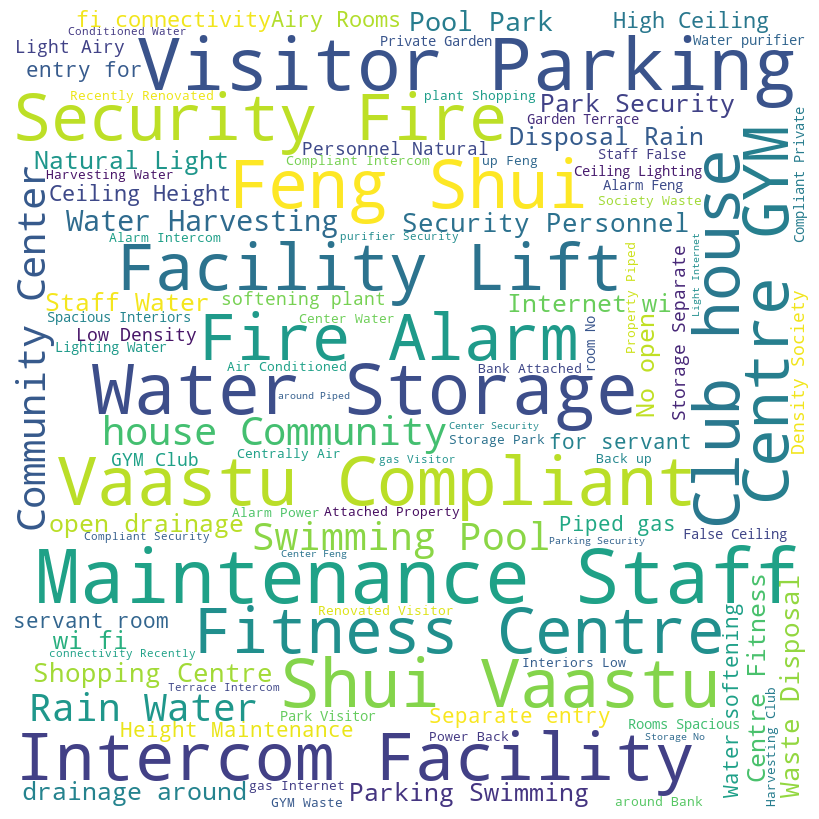

In [42]:
plt.rcParams["font.family"] = "Arial"

wordcloud = WordCloud(width = 800, height = 800, 
                      background_color ='white', 
                      stopwords = set(['s']),  # Any stopwords you'd like to exclude
                      min_font_size = 10).generate(feature_text)

plt.figure(figsize = (8, 8), facecolor = None) 
plt.imshow(wordcloud, interpolation='bilinear') 
plt.axis("off") 
plt.tight_layout(pad = 0) 
plt.show()

In [43]:
data = dict(
    names=["A", "B", "C", "D", "E", "F"],
    parents=["", "", "", "A", "A", "C"],
    values=[10, 20, 30, 40, 50, 60],
)

fig = px.sunburst(
    df1,
    names='property_type',
    values='price_per_sqft',
    parents='bedRoom',
    title="Sample Sunburst Chart"
)
fig.show()

In [44]:
fig = px.scatter(df, x="built_up_area", y="price", color="bedRoom", title="Area Vs Price")

# Show the plot
fig.show()

In [45]:
fig = px.pie(df, names='bedRoom', title='Total Bill Amount by Day')

# Show the plot
fig.show()

In [46]:
temp_df = df[df['bedRoom'] <= 4]
# Create side-by-side boxplots of the total bill amounts by day
fig = px.box(temp_df, x='bedRoom', y='price', title='BHK Price Range')

# Show the plot
fig.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_11652\3761596323.py:1: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751


C:\Users\DELL\AppData\Local\Temp\ipykernel_11652\3761596323.py:2: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751




<Axes: xlabel='price', ylabel='Density'>

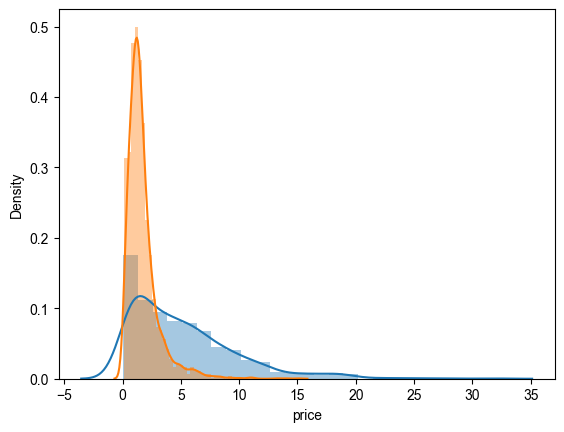

In [47]:
sns.distplot(df[df['property_type'] == 'house']['price'])
sns.distplot(df[df['property_type'] == 'flat']['price'])

In [48]:
new_df['sector'].unique().tolist().insert(0,'overall')